In [1]:
import pandas as pd
import numpy as np

df = pd.read_excel("Shoe-shop-hypo.xlsx", sheet_name="Al Bundy", skiprows=3)

df.head(5)

,Unnamed: 0,InvoiceNo,Date,Country,ProductID,Shop,Gender,Size (US),UnitPrice,Discount,Unnamed: 10,Month,SalePrice
0,NaN,52389,2014-01-01 01:06:24,United Kingdom,2152,UK2,Male,11.0,159,0.0,2014,1,159.0
1,NaN,52390,2014-01-01 03:44:48,United States,2230,US15,Male,11.5,199,0.2,2014,1,159.2
2,NaN,52391,2014-01-01 09:01:36,Canada,2160,CAN7,Male,9.5,149,0.2,2014,1,119.2
3,NaN,52392,2014-01-01 09:16:00,United States,2234,US6,Female,9.5,159,0.0,2014,1,159.0
4,NaN,52393,2014-01-01 13:35:12,United Kingdom,2222,UK4,Female,9.0,159,0.0,2014,1,159.0


int64
0        159
1        199
2        149
3        159
4        159
        ... 
14962    139
14963    149
14964    179
14965    199
14966    139
Name: UnitPrice, Length: 14967, dtype: int64


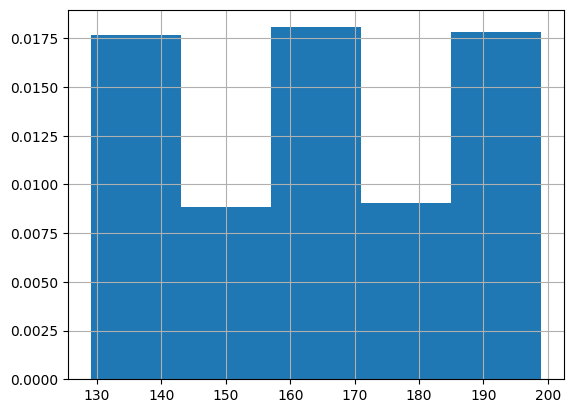

In [2]:
# unitprice = df["UnitPrice"].astype("float64")
unitprice = pd.to_numeric(df["UnitPrice"], errors='coerce')
unitprice_type = df["UnitPrice"].dtype
print(unitprice_type)

(unitprice).hist(density=True, bins=5)

# saleprice = df["SalePrice"].astype("float64")
# saleprice.hist(density=True, bins=5)
# unitprice.plot.kde()

print(unitprice)

Population mean: 164.17137702946482
Sample mean: 159.4
Bootstrap mean: 159.2996


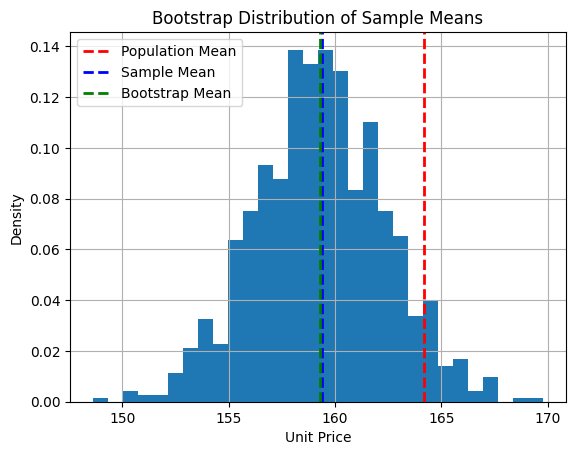

In [3]:
bootstrap_50  = unitprice.sample(n= 50, random_state=42)
bootstrap_means = [bootstrap_50.sample(n= 50, replace=True).mean() for _ in range(1000)]

mean = unitprice.mean()
sample_mean = bootstrap_50.mean()
bootstrap_mean = np.mean(bootstrap_means)

print(f"Population mean: {mean}")
print(f"Sample mean: {sample_mean}")
print(f"Bootstrap mean: {bootstrap_mean}")

import matplotlib.pyplot as plt
pd.Series(bootstrap_means).hist(density=True, bins=30)
plt.axvline(mean, color='red', linestyle='dashed', linewidth=2, label='Population Mean')
plt.axvline(sample_mean, color='blue', linestyle='dashed', linewidth=2, label='Sample Mean')
plt.axvline(bootstrap_mean, color='green', linestyle='dashed', linewidth=2, label='Bootstrap Mean')
plt.legend()
plt.title('Bootstrap Distribution of Sample Means')
plt.xlabel('Unit Price')
plt.ylabel('Density')
plt.show()


In [16]:
import scipy.stats as stats
saleprice = pd.to_numeric(df["SalePrice"], errors='coerce')
# saleprice.hist(density=True, bins=5)

bootstrap_50_saleprice  = saleprice.sample(n= 50, random_state=42)
bootstrap_means_saleprice = [bootstrap_50_saleprice.sample(n= 50, replace=True).mean() for _ in range(1000)]
mean_saleprice = saleprice.mean()

interval_t = stats.t.interval(0.90, len(bootstrap_means_saleprice)-1, loc=np.mean(bootstrap_means_saleprice), scale=stats.sem(bootstrap_means_saleprice))
interval_bootstrap = np.percentile(bootstrap_means_saleprice, [10, 90])
print(f"90% Confidence Interval for Sale Price: {interval_t}")
print(f"90% Bootstrap Confidence Interval for Sale Price: {interval_bootstrap}")

90% Confidence Interval for Sale Price: (np.float64(138.89629796908636), np.float64(139.42688603091366))
90% Bootstrap Confidence Interval for Sale Price: [132.3772 145.5384]


In [17]:
# task 4
#h0: there is no significant differece in discount between the gender of man and woman
#h1: there is significant differece in discount between the gender

pvalue = stats.ttest_ind(df[df['Gender'] == 'Male']['Discount'], df[df['Gender'] == 'Female']['Discount']).pvalue
print(f"P-value for the t-test: {pvalue}")
if pvalue > 0.05:
    print("Fail to reject H0: No significant difference in discount")

pvalue_gender_unitprice = stats.ttest_ind(df[df['Gender'] == 'Male']['UnitPrice'], df[df['Gender'] == 'Female']['UnitPrice']).pvalue
print(f"P-value for the t-test on UnitPrice: {pvalue_gender_unitprice}")
if pvalue_gender_unitprice > 0.05:
    print("Fail to reject H0: No significant difference in unit price between   genders")

P-value for the t-test: 0.880947571883521
Fail to reject H0: No significant difference in discount
P-value for the t-test on UnitPrice: 0.2532449676995263
Fail to reject H0: No significant difference in unit price between   genders


In [18]:
#task 5
# h0: there is no signifiant difference in discount between different countries
# h1: there is signifiant difference in discount between different countries
countries = df['Country'].unique()
discounts_by_country = [df[df['Country'] == country]['Discount'] for country in countries]
pvalue_country_discount = stats.f_oneway(*discounts_by_country).pvalue
print(f"P-value for the ANOVA test on Discount by Country: {pvalue_country_discount}")
if pvalue_country_discount > 0.05:
    print("Fail to reject H0: No significant difference in discount between countries")

P-value for the ANOVA test on Discount by Country: 0.5312762967063773
Fail to reject H0: No significant difference in discount between countries


In [19]:
#task 6 
# h0: gender and country are independent, they have no relationship
# h1: gender and country are not independent, they have relationship

from matplotlib.pylab import cross


cross_tab_gender_country = pd.crosstab(df['Country'], df['Gender'])

cross_tab_gender_country["Female_normalized"] = cross_tab_gender_country["Female"] / cross_tab_gender_country.sum(axis=1)
cross_tab_gender_country["Male_normalized"] = cross_tab_gender_country["Male"] / cross_tab_gender_country.sum(axis=1)

cross_tab_gender_country = cross_tab_gender_country[["Female_normalized", "Male_normalized"]]
cross_tab_gender_country.columns = ["Female", "Male"]

cross_tab_gender_country

chi2_test = stats.chi2_contingency(cross_tab_gender_country)
pvalue_chi2 = chi2_test.pvalue
print(f"P-value for the chi-squared test: {pvalue_chi2}")
if pvalue_chi2 > 0.05:
    print("Fail to reject H0: Gender and Country are independent")


P-value for the chi-squared test: 0.9999298385622984
Fail to reject H0: Gender and Country are independent
